# Lecture 3: Diversification, Portfolio Risk, and Markowitz Optimization

## Investment Analysis

This lecture builds on the previous two notebooks.

Lecture 1 introduced returns, return measurement, compounding, taxes, risk statistics, and the stochastic discount factor.

Lecture 2 introduced utility, risk aversion, certainty equivalents, the capital allocation line, the Sharpe ratio, and the investor's optimal allocation between a risk-free asset and a risky portfolio.

This lecture studies the central idea of modern portfolio theory:

> Investors should usually care about the risk of the whole portfolio, not the risk of each asset in isolation.

That insight leads to diversification, covariance, the minimum-variance frontier, the efficient frontier, the tangency portfolio, the capital market line, the separation property, and the Markowitz portfolio optimization problem.

# 1. Learning Objectives

By the end of this lecture, students should be able to:

1. Explain the insurance principle and the law of large numbers.
2. Distinguish systematic risk from diversifiable firm-specific risk.
3. Calculate expected return and variance for a two-risky-asset portfolio.
4. Explain why the variance of an asset is its covariance with itself.
5. Interpret covariance, correlation, and the covariance matrix.
6. Calculate the standard deviation of a three-asset portfolio.
7. Explain hedge assets and negative correlation.
8. Interpret portfolio weights below 0 and above 1.
9. Trace the minimum-variance portfolio and the minimum-variance frontier.
10. Explain how the efficient frontier changes with correlation.
11. Combine a risky portfolio with the risk-free asset.
12. Identify the tangency portfolio that maximizes the Sharpe ratio.
13. Derive the optimal complete portfolio from investor risk aversion.
14. Understand the Markowitz optimization model with many risky assets.
15. Explain short-selling constraints and the separation property.

# 2. Setup: Python Libraries

We will use `numpy`, `pandas`, and `matplotlib`.

The examples are deliberately stylized. The goal is not to estimate a real-world portfolio perfectly, but to make the logic of diversification and portfolio choice transparent.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

Matplotlib is building the font cache; this may take a moment.


# 3. Why Diversification Matters

Suppose an investor holds only one stock. The investor is exposed to everything that can happen to that firm:

- a factory fire,
- a failed product,
- a labor dispute,
- a lawsuit,
- a bad acquisition,
- an accounting scandal,
- a management mistake.

Some of those events are firm-specific. They affect one company but not necessarily the whole market.

If the investor holds many imperfectly correlated assets, firm-specific shocks can offset each other.

This is the **insurance principle**:

> When independent or imperfectly correlated risks are pooled together, the risk of the aggregate portfolio can be smaller than the risk of the individual components.

This is closely connected to the **law of large numbers**.

If a portfolio contains many independent risks, the average outcome becomes more predictable than any individual outcome.

# 4. The Insurance Principle and the Law of Large Numbers

Suppose each asset has return:

$$
R_i = \mu + \epsilon_i
$$

where:

- \( \mu \) is the common expected return,
- \( \epsilon_i \) is a firm-specific shock,
- \( \mathbb{E}[\epsilon_i] = 0 \),
- firm-specific shocks are independent across firms.

If a portfolio holds \( N \) equally weighted assets, then:

$$
R_p = \frac{1}{N}\sum_{i=1}^N R_i
$$

Substitute:

$$
R_p = \mu + \frac{1}{N}\sum_{i=1}^N \epsilon_i
$$

If the shocks are independent with common variance \( \sigma_\epsilon^2 \), then:

$$
\operatorname{Var}(R_p)
=
\operatorname{Var}\left(\frac{1}{N}\sum_{i=1}^N \epsilon_i\right)
$$

Because the shocks are independent:

$$
\operatorname{Var}(R_p)
=
\frac{1}{N^2}N\sigma_\epsilon^2
=
\frac{\sigma_\epsilon^2}{N}
$$

As \( N \) rises, the firm-specific component of risk shrinks.

$$
\lim_{N \to \infty} \frac{\sigma_\epsilon^2}{N} = 0
$$

This is why diversification can eliminate independent firm-specific risk.

In [2]:
N_values = np.arange(1, 101)
sigma_firm = 0.30
portfolio_std_independent = sigma_firm / np.sqrt(N_values)

demo = pd.DataFrame({
    "Number of Assets": N_values,
    "Portfolio Std Dev with Independent Firm-Specific Risk": portfolio_std_independent
})
demo.head(10)

,Number of Assets,Portfolio Std Dev with Independent Firm-Specific Risk
0,1,0.3000
1,2,0.2121
2,3,0.1732
3,4,0.1500
4,5,0.1342
5,6,0.1225
6,7,0.1134
7,8,0.1061
8,9,0.1000
9,10,0.0949


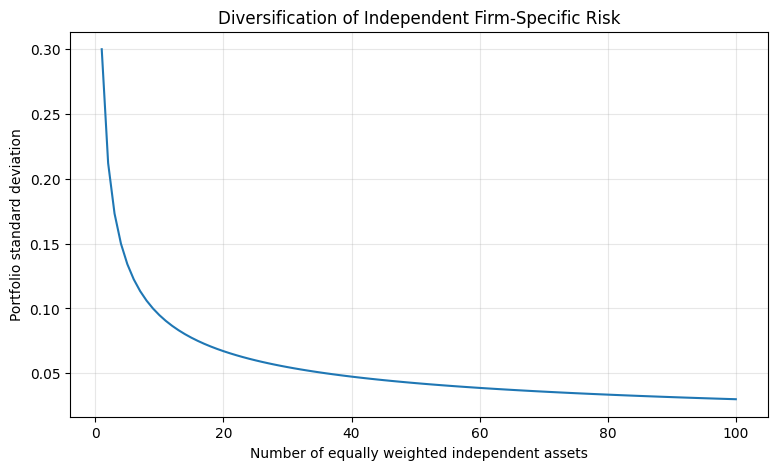

In [3]:
plt.figure(figsize=(9, 5))
plt.plot(N_values, portfolio_std_independent)
plt.xlabel("Number of equally weighted independent assets")
plt.ylabel("Portfolio standard deviation")
plt.title("Diversification of Independent Firm-Specific Risk")
plt.grid(True, alpha=0.3)
plt.show()

The graph shows the basic logic of diversification.

The first few assets reduce risk substantially. After the portfolio is already diversified, adding more assets still helps, but the marginal benefit is smaller.

# 5. Systematic Risk Versus Unsystematic Risk

In real financial markets, not all risks are independent. Many firms are exposed to common shocks:

- recessions,
- inflation surprises,
- interest-rate shocks,
- oil-price shocks,
- credit crises,
- exchange-rate shocks,
- tax and regulatory shocks,
- changes in monetary policy,
- changes in aggregate demand.

A simple one-factor model writes the return on asset \( i \) as:

$$
R_i = \alpha_i + \beta_i R_m + \epsilon_i
$$

where:

- \( R_m \) is the marketwide factor,
- \( \beta_i \) measures the asset's sensitivity to the market factor,
- \( \epsilon_i \) is firm-specific risk.

The variance of asset \( i \) is:

$$
\operatorname{Var}(R_i)
=
\beta_i^2 \operatorname{Var}(R_m)
+
\operatorname{Var}(\epsilon_i)
+
2\beta_i \operatorname{Cov}(R_m,\epsilon_i)
$$

If the firm-specific shock is uncorrelated with the market factor, then:

$$
\operatorname{Cov}(R_m,\epsilon_i)=0
$$

and:

$$
\operatorname{Var}(R_i)
=
\beta_i^2 \sigma_m^2
+
\sigma_{\epsilon_i}^2
$$

The market factor component is **systematic risk**.

The firm-specific component is **unsystematic risk**.

Diversification can reduce unsystematic risk, but it cannot eliminate systematic risk.

In [4]:
N_values = np.arange(1, 301)
sigma_market = 0.18
beta = 1.0
sigma_idiosyncratic = 0.30

portfolio_var_with_market = (beta**2) * (sigma_market**2) + (sigma_idiosyncratic**2) / N_values
portfolio_std_with_market = np.sqrt(portfolio_var_with_market)

pd.DataFrame({
    "N": [1, 5, 10, 25, 50, 100, 300],
    "Portfolio Std Dev": [portfolio_std_with_market[n-1] for n in [1, 5, 10, 25, 50, 100, 300]]
})

,N,Portfolio Std Dev
0,1,0.3499
1,5,0.2245
2,10,0.2035
3,25,0.1897
4,50,0.1849
5,100,0.1825
6,300,0.1808


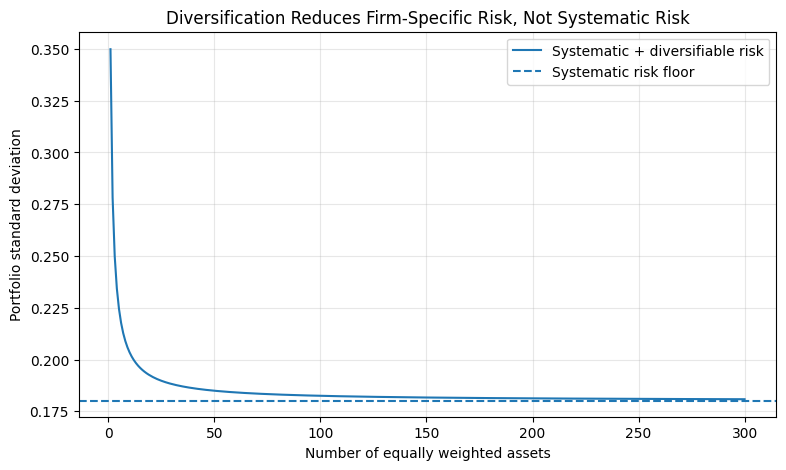

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(N_values, portfolio_std_with_market, label="Systematic + diversifiable risk")
plt.axhline(sigma_market, linestyle="--", label="Systematic risk floor")
plt.xlabel("Number of equally weighted assets")
plt.ylabel("Portfolio standard deviation")
plt.title("Diversification Reduces Firm-Specific Risk, Not Systematic Risk")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The curve falls at first because firm-specific risk is being diversified away.

But the curve approaches a risk floor. That floor is systematic risk.

This is why a broad stock portfolio remains risky even if it owns hundreds or thousands of stocks.

# 6. Expected Return of a Portfolio

Let a portfolio contain \( N \) risky assets.

Let \( w_i \) be the weight on asset \( i \). The weights sum to one:

$$
\sum_{i=1}^N w_i = 1
$$

Let the expected return on asset \( i \) be \( \mathbb{E}[R_i] \).

The expected return on the portfolio is the weighted average:

$$
\mathbb{E}[R_p]
=
\sum_{i=1}^N w_i \mathbb{E}[R_i]
$$

In vector notation:

$$
\mathbb{E}[R_p] = \mathbf{w}'\boldsymbol{\mu}
$$

where:

- \( \mathbf{w} \) is the vector of portfolio weights,
- \( \boldsymbol{\mu} \) is the vector of expected returns.

Expected return is linear in the weights.

Risk is not linear in the weights, because covariances matter.

In [6]:
mu = np.array([0.06, 0.10, 0.14])
weights = np.array([0.50, 0.30, 0.20])
expected_portfolio_return = weights @ mu

pd.DataFrame({
    "Asset": ["Bond Fund", "Broad Equity", "Small-Cap Equity"],
    "Weight": weights,
    "Expected Return": mu,
    "Contribution to Expected Return": weights * mu
})

,Asset,Weight,Expected Return,Contribution to Expected Return
0,Bond Fund,0.5000,0.0600,0.0300
1,Broad Equity,0.3000,0.1000,0.0300
2,Small-Cap Equity,0.2000,0.1400,0.0280


In [7]:
print(f"Expected portfolio return = {expected_portfolio_return:.2%}")

Expected portfolio return = 8.80%


# 7. Covariance and Correlation

The variance of a single asset's return is:

$$
\operatorname{Var}(R_i)
=
\mathbb{E}[(R_i-\mu_i)^2]
$$

Covariance between two asset returns is:

$$
\operatorname{Cov}(R_i,R_j)
=
\mathbb{E}[(R_i-\mu_i)(R_j-\mu_j)]
$$

If the covariance is positive, the returns tend to move together.

If the covariance is negative, one asset tends to do well when the other does poorly.

If the covariance is near zero, the linear relationship is weak.

A crucial identity is:

$$
\operatorname{Var}(R_i)
=
\operatorname{Cov}(R_i,R_i)
$$

The variance of an asset is the covariance of the asset with itself.

That is why the covariance matrix has variances on the diagonal and covariances off the diagonal.

Correlation rescales covariance to lie between \(-1\) and \(+1\):

$$
\rho_{ij}
=
\frac{\operatorname{Cov}(R_i,R_j)}{\sigma_i\sigma_j}
$$

Equivalently:

$$
\operatorname{Cov}(R_i,R_j)
=
\rho_{ij}\sigma_i\sigma_j
$$

Correlation is easier to interpret than covariance because it is unit-free.

In [8]:
returns = pd.DataFrame({
    "Asset A": np.random.normal(0.08/12, 0.16/np.sqrt(12), 120),
    "Asset B": np.random.normal(0.10/12, 0.22/np.sqrt(12), 120)
})

cov_matrix_sample = returns.cov()
var_asset_a = returns["Asset A"].var(ddof=1)
cov_a_a = cov_matrix_sample.loc["Asset A", "Asset A"]

print(f"Sample variance of Asset A:        {var_asset_a:.8f}")
print(f"Covariance of Asset A with itself: {cov_a_a:.8f}")
cov_matrix_sample

Sample variance of Asset A:        0.00182658
Covariance of Asset A with itself: 0.00182658


,Asset A,Asset B
Asset A,0.0018,0.0003
Asset B,0.0003,0.0041


# 8. Two Risky Assets: Expected Return and Standard Deviation

Suppose a portfolio contains two risky assets, \( A \) and \( B \).

Let:

- \( w_A \) be the weight in asset \( A \),
- \( w_B = 1-w_A \) be the weight in asset \( B \),
- \( \mu_A \) and \( \mu_B \) be expected returns,
- \( \sigma_A \) and \( \sigma_B \) be standard deviations,
- \( \rho_{AB} \) be the correlation coefficient.

Expected return is:

$$
\mathbb{E}[R_p]
=
w_A\mu_A + w_B\mu_B
$$

Portfolio variance is:

$$
\sigma_p^2
=
w_A^2\sigma_A^2
+
w_B^2\sigma_B^2
+
2w_Aw_B\operatorname{Cov}(R_A,R_B)
$$

Using correlation:

$$
\sigma_p^2
=
w_A^2\sigma_A^2
+
w_B^2\sigma_B^2
+
2w_Aw_B\rho_{AB}\sigma_A\sigma_B
$$

Portfolio standard deviation is:

$$
\sigma_p = \sqrt{\sigma_p^2}
$$

## Worked Example 1: Two Risky Assets

Suppose:

$$
\mu_A = 8\%, \quad \sigma_A = 15\%
$$

$$
\mu_B = 12\%, \quad \sigma_B = 25\%
$$

$$
\rho_{AB} = 0.30
$$

The investor puts 60% in asset \( A \) and 40% in asset \( B \).

Then:

$$
\mathbb{E}[R_p]
=
0.60(0.08)+0.40(0.12)
=
0.096
$$

So expected return is 9.6%.

The variance is:

$$
\sigma_p^2
=
(0.60)^2(0.15)^2
+
(0.40)^2(0.25)^2
+
2(0.60)(0.40)(0.30)(0.15)(0.25)
$$

In [9]:
mu_A, mu_B = 0.08, 0.12
sigma_A, sigma_B = 0.15, 0.25
rho_AB = 0.30
w_A = 0.60
w_B = 1 - w_A

expected_return = w_A * mu_A + w_B * mu_B
variance = (w_A**2 * sigma_A**2 
            + w_B**2 * sigma_B**2
            + 2 * w_A * w_B * rho_AB * sigma_A * sigma_B)
std_dev = np.sqrt(variance)

print(f"Expected return: {expected_return:.2%}")
print(f"Portfolio variance: {variance:.6f}")
print(f"Portfolio standard deviation: {std_dev:.2%}")

Expected return: 9.60%
Portfolio variance: 0.023500
Portfolio standard deviation: 15.33%


The portfolio standard deviation is not the weighted average of the two standard deviations.

The weighted average of standard deviations would be:

$$
0.60(15\%) + 0.40(25\%) = 19\%
$$

But because correlation is less than one, diversification lowers portfolio risk below 19%.

# 9. How Correlation Changes the Diversification Benefit

The diversification benefit depends critically on correlation.

If \( \rho = +1 \), the assets move perfectly together. There is no curvature in the portfolio frontier.

If \( \rho < +1 \), diversification lowers risk.

If \( \rho = -1 \), it may be possible to construct a zero-risk portfolio from two risky assets.

The formula:

$$
\sigma_p^2
=
w_A^2\sigma_A^2
+
(1-w_A)^2\sigma_B^2
+
2w_A(1-w_A)\rho_{AB}\sigma_A\sigma_B
$$

shows how portfolio risk changes as a function of the asset weight and the correlation coefficient.

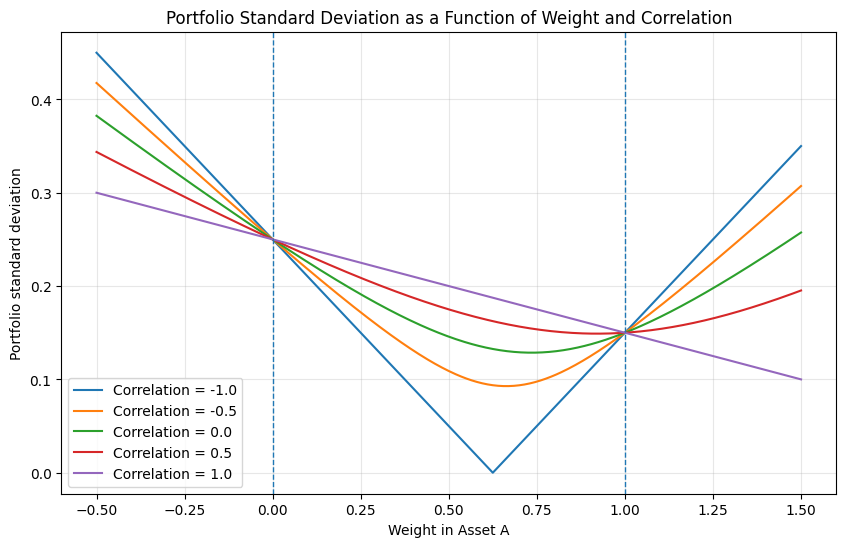

In [10]:
weights_A = np.linspace(-0.5, 1.5, 401)
correlations = [-1.0, -0.5, 0.0, 0.5, 1.0]
std_by_corr = {}

for rho in correlations:
    wA = weights_A
    wB = 1 - wA
    var_p = (wA**2 * sigma_A**2 
             + wB**2 * sigma_B**2 
             + 2*wA*wB*rho*sigma_A*sigma_B)
    std_by_corr[rho] = np.sqrt(np.maximum(var_p, 0))

plt.figure(figsize=(10, 6))
for rho, stds in std_by_corr.items():
    plt.plot(weights_A, stds, label=f"Correlation = {rho:.1f}")

plt.axvline(0, linestyle="--", linewidth=1)
plt.axvline(1, linestyle="--", linewidth=1)
plt.xlabel("Weight in Asset A")
plt.ylabel("Portfolio standard deviation")
plt.title("Portfolio Standard Deviation as a Function of Weight and Correlation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The vertical lines at \( w_A=0 \) and \( w_A=1 \) mark the no-short-sale region.

Weights between 0 and 1 mean the investor holds positive amounts of both assets.

Weights below 0 or above 1 involve short selling or leverage. Those cases are discussed below.

# 10. Hedge Assets and Negative Correlation

A **hedge asset** is valuable because it offsets risk in the rest of the portfolio.

An asset can have a low expected return and still be valuable if it has negative correlation with the investor's other assets.

For example:

- long-duration Treasury bonds may hedge recessions in some historical environments,
- put options hedge large equity losses,
- commodity exposure may hedge some inflation shocks,
- foreign assets may hedge domestic risks,
- cash hedges liquidity needs.

A hedge asset's value comes from its covariance properties.

The same asset may be a hedge for one investor and a source of risk for another investor. Hedging is portfolio-specific.

In [11]:
mu_risky = 0.10
sigma_risky = 0.22
mu_hedge = 0.03
sigma_hedge = 0.12
rho_hedge = -0.40

weights_hedge = np.linspace(0, 0.8, 161)
portfolio_mu = (1 - weights_hedge) * mu_risky + weights_hedge * mu_hedge
portfolio_var = ((1 - weights_hedge)**2 * sigma_risky**2 
                 + weights_hedge**2 * sigma_hedge**2
                 + 2*(1 - weights_hedge)*weights_hedge*rho_hedge*sigma_risky*sigma_hedge)
portfolio_sigma = np.sqrt(portfolio_var)

pd.DataFrame({
    "Hedge Weight": weights_hedge,
    "Expected Return": portfolio_mu,
    "Standard Deviation": portfolio_sigma
}).iloc[[0, 20, 40, 80, 120, 160]]

,Hedge Weight,Expected Return,Standard Deviation
0,0.0000,0.1000,0.2200
20,0.1000,0.0930,0.1935
40,0.2000,0.0860,0.1678
80,0.4000,0.0720,0.1211
120,0.6000,0.0580,0.0887
160,0.8000,0.0440,0.0882


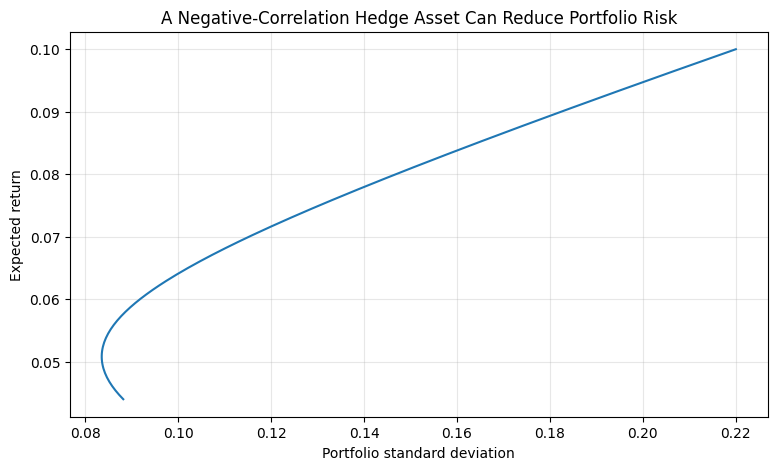

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(portfolio_sigma, portfolio_mu)
plt.xlabel("Portfolio standard deviation")
plt.ylabel("Expected return")
plt.title("A Negative-Correlation Hedge Asset Can Reduce Portfolio Risk")
plt.grid(True, alpha=0.3)
plt.show()

The hedge asset has a lower expected return, but modest allocations to it may substantially reduce total portfolio volatility.

This is the economic reason a rational investor may hold an asset that looks unattractive in isolation.

# 11. Interpreting Portfolio Weights Below 0 or Above 1

Portfolio weights do not have to lie between 0 and 1 unless short sales and borrowing are prohibited.

A weight greater than 1 means the investor holds more than 100% of wealth in that asset. This requires borrowing or shorting another asset.

A weight below 0 means the investor is short that asset.

Example:

$$
w_A = 1.30, \quad w_B = -0.30
$$

This means:

- invest 130% of wealth in asset \( A \),
- finance part of that position by shorting 30% of wealth in asset \( B \).

Because:

$$
1.30 + (-0.30) = 1.00
$$

the weights still sum to one.

In equity markets, a negative weight means short selling stock. In debt markets, it may mean issuing debt or taking the opposite side of a bond exposure.

The economic meaning is always the same:

> A negative weight means the investor benefits when that asset's return is low and loses when that asset's return is high.

In [13]:
wA_values = [0.60, 1.00, 1.30, -0.30]
rows = []
for wA in wA_values:
    wB = 1 - wA
    mu_p = wA * mu_A + wB * mu_B
    var_p = wA**2 * sigma_A**2 + wB**2 * sigma_B**2 + 2*wA*wB*rho_AB*sigma_A*sigma_B
    rows.append([wA, wB, mu_p, np.sqrt(var_p)])

pd.DataFrame(rows, columns=["Weight A", "Weight B", "Expected Return", "Std Dev"])

,Weight A,Weight B,Expected Return,Std Dev
0,0.6000,0.4000,0.0960,0.1533
1,1.0000,0.0000,0.0800,0.1500
2,1.3000,-0.3000,0.0680,0.1867
3,-0.3000,1.3000,0.1320,0.3144


# 12. The Minimum-Variance Portfolio with Two Risky Assets

For two risky assets, the minimum-variance portfolio is the weight \( w_A \) that minimizes:

$$
\sigma_p^2
=
w_A^2\sigma_A^2
+
(1-w_A)^2\sigma_B^2
+
2w_A(1-w_A)\sigma_{AB}
$$

where:

$$
\sigma_{AB}=\operatorname{Cov}(R_A,R_B)
$$

The closed-form solution is:

$$
w_A^{MVP}
=
\frac{\sigma_B^2-\sigma_{AB}}
{\sigma_A^2+\sigma_B^2-2\sigma_{AB}}
$$

and:

$$
w_B^{MVP}=1-w_A^{MVP}
$$

This portfolio minimizes variance among all combinations of the two risky assets.

In [14]:
cov_AB = rho_AB * sigma_A * sigma_B

w_A_mvp = (sigma_B**2 - cov_AB) / (sigma_A**2 + sigma_B**2 - 2*cov_AB)
w_B_mvp = 1 - w_A_mvp

mu_mvp = w_A_mvp * mu_A + w_B_mvp * mu_B
var_mvp = w_A_mvp**2 * sigma_A**2 + w_B_mvp**2 * sigma_B**2 + 2*w_A_mvp*w_B_mvp*cov_AB
sigma_mvp = np.sqrt(var_mvp)

print(f"Minimum-variance weight in Asset A: {w_A_mvp:.4f}")
print(f"Minimum-variance weight in Asset B: {w_B_mvp:.4f}")
print(f"MVP expected return: {mu_mvp:.2%}")
print(f"MVP standard deviation: {sigma_mvp:.2%}")

Minimum-variance weight in Asset A: 0.8200
Minimum-variance weight in Asset B: 0.1800
MVP expected return: 8.72%
MVP standard deviation: 14.31%


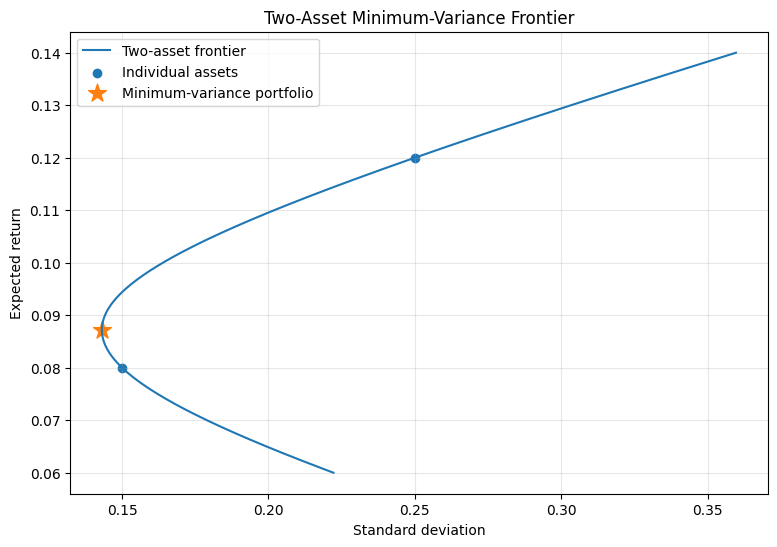

In [15]:
weights_A_frontier = np.linspace(-0.5, 1.5, 501)
frontier_mu = weights_A_frontier*mu_A + (1-weights_A_frontier)*mu_B
frontier_var = (weights_A_frontier**2*sigma_A**2 
                + (1-weights_A_frontier)**2*sigma_B**2 
                + 2*weights_A_frontier*(1-weights_A_frontier)*cov_AB)
frontier_sigma = np.sqrt(frontier_var)

plt.figure(figsize=(9, 6))
plt.plot(frontier_sigma, frontier_mu, label="Two-asset frontier")
plt.scatter([sigma_A, sigma_B], [mu_A, mu_B], marker="o", label="Individual assets")
plt.scatter([sigma_mvp], [mu_mvp], marker="*", s=180, label="Minimum-variance portfolio")
plt.xlabel("Standard deviation")
plt.ylabel("Expected return")
plt.title("Two-Asset Minimum-Variance Frontier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The upper part of the frontier is efficient relative to the lower part.

For a given standard deviation, investors prefer the portfolio with the higher expected return.

For a given expected return, investors prefer the portfolio with the lower standard deviation.

# 13. How the Frontier Changes with Correlation

The lower the correlation between assets, the more the frontier bends to the left.

That leftward bend represents the diversification benefit.

When correlation is high, portfolios look more like simple weighted averages of the two assets.

When correlation is low or negative, combining assets can produce a portfolio with much lower risk than either asset alone.

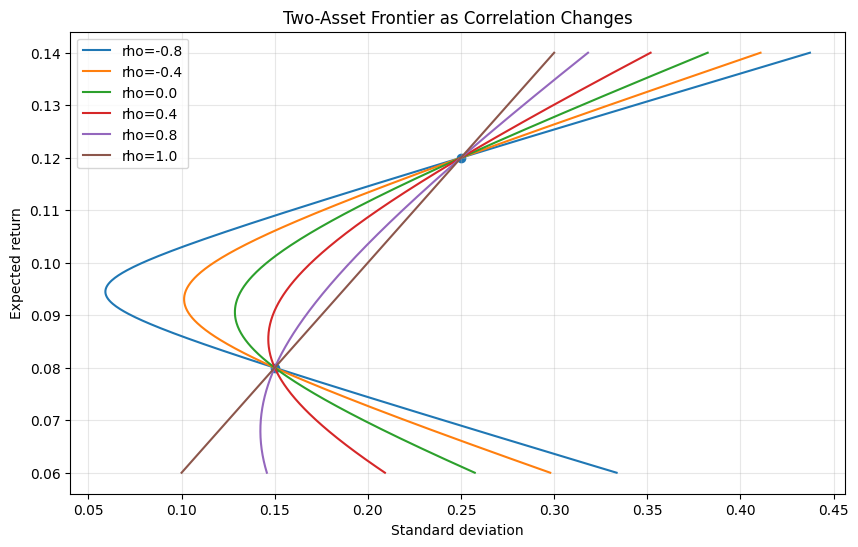

In [16]:
plt.figure(figsize=(10, 6))
for rho in [-0.8, -0.4, 0.0, 0.4, 0.8, 1.0]:
    cov = rho * sigma_A * sigma_B
    var = (weights_A_frontier**2*sigma_A**2 
           + (1-weights_A_frontier)**2*sigma_B**2
           + 2*weights_A_frontier*(1-weights_A_frontier)*cov)
    sigma = np.sqrt(np.maximum(var, 0))
    mu_line = weights_A_frontier*mu_A + (1-weights_A_frontier)*mu_B
    plt.plot(sigma, mu_line, label=f"rho={rho:.1f}")

plt.scatter([sigma_A, sigma_B], [mu_A, mu_B], marker="o")
plt.xlabel("Standard deviation")
plt.ylabel("Expected return")
plt.title("Two-Asset Frontier as Correlation Changes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The expected return line as a function of weights does not depend on correlation.

The risk of the portfolio does depend on correlation.

Therefore, correlation changes the shape and attractiveness of the opportunity set.

# 14. Three-Asset Portfolios and the Covariance Matrix

For three assets, the expected return is still a weighted average:

$$
\mathbb{E}[R_p]
=
w_1\mu_1+w_2\mu_2+w_3\mu_3
$$

Portfolio variance is:

$$
\sigma_p^2
=
w_1^2\sigma_1^2
+
w_2^2\sigma_2^2
+
w_3^2\sigma_3^2
+
2w_1w_2\sigma_{12}
+
2w_1w_3\sigma_{13}
+
2w_2w_3\sigma_{23}
$$

In vector notation:

$$
\sigma_p^2 = \mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
$$

where \( \boldsymbol{\Sigma} \) is the covariance matrix:

$$
\boldsymbol{\Sigma}
=
\begin{bmatrix}
\sigma_1^2 & \sigma_{12} & \sigma_{13} \\
\sigma_{21} & \sigma_2^2 & \sigma_{23} \\
\sigma_{31} & \sigma_{32} & \sigma_3^2
\end{bmatrix}
$$

The covariance matrix is symmetric because:

$$
\operatorname{Cov}(R_i,R_j)=\operatorname{Cov}(R_j,R_i)
$$

## Worked Example 2: A Three-Asset Portfolio

Suppose expected returns are:

$$
\boldsymbol{\mu}
=
\begin{bmatrix}
0.06 \\
0.10 \\
0.14
\end{bmatrix}
$$

and portfolio weights are:

$$
\mathbf{w}
=
\begin{bmatrix}
0.50 \\
0.30 \\
0.20
\end{bmatrix}
$$

Suppose the covariance matrix is:

$$
\boldsymbol{\Sigma}
=
\begin{bmatrix}
0.0100 & 0.0060 & 0.0040 \\
0.0060 & 0.0400 & 0.0180 \\
0.0040 & 0.0180 & 0.0900
\end{bmatrix}
$$

Then:

$$
\mathbb{E}[R_p] = \mathbf{w}'\boldsymbol{\mu}
$$

and:

$$
\sigma_p = \sqrt{\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}}
$$

In [17]:
mu3 = np.array([0.06, 0.10, 0.14])
w3 = np.array([0.50, 0.30, 0.20])

Sigma3 = np.array([
    [0.0100, 0.0060, 0.0040],
    [0.0060, 0.0400, 0.0180],
    [0.0040, 0.0180, 0.0900]
])

expected_return_3 = w3 @ mu3
variance_3 = w3 @ Sigma3 @ w3
std_3 = np.sqrt(variance_3)

print(f"Expected return: {expected_return_3:.2%}")
print(f"Variance: {variance_3:.6f}")
print(f"Standard deviation: {std_3:.2%}")

pd.DataFrame(Sigma3, index=["Asset 1", "Asset 2", "Asset 3"], columns=["Asset 1", "Asset 2", "Asset 3"])

Expected return: 8.80%
Variance: 0.014460
Standard deviation: 12.02%


,Asset 1,Asset 2,Asset 3
Asset 1,0.0100,0.0060,0.0040
Asset 2,0.0060,0.0400,0.0180
Asset 3,0.0040,0.0180,0.0900


The matrix formula is compact and general. It works for three assets, thirty assets, or three thousand assets.

The practical problem is that the covariance matrix becomes large as the number of assets increases.

For \( N \) assets, there are \( N \) variances and:

$$
\frac{N(N-1)}{2}
$$

distinct covariances.

This is one reason portfolio optimization is statistically demanding.

# 15. Simulating a Three-Asset Portfolio

The formulas above can be verified with simulated returns.

We will create three correlated return series, compute sample means and covariances, and then calculate portfolio statistics.

In [18]:
annual_mu = np.array([0.06, 0.10, 0.14])
annual_vol = np.array([0.10, 0.20, 0.30])

corr3 = np.array([
    [1.00, 0.30, 0.10],
    [0.30, 1.00, 0.45],
    [0.10, 0.45, 1.00]
])

annual_cov = np.outer(annual_vol, annual_vol) * corr3
monthly_mu = annual_mu / 12
monthly_cov = annual_cov / 12

sim_returns = np.random.multivariate_normal(monthly_mu, monthly_cov, size=240)
sim_returns = pd.DataFrame(sim_returns, columns=["Asset 1", "Asset 2", "Asset 3"])
sim_returns.head()

,Asset 1,Asset 2,Asset 3
0,-0.0136,-0.0231,-0.0533
1,0.0056,-0.0141,0.1089
2,-0.0509,-0.0275,-0.0171
3,-0.0305,-0.0264,0.0700
4,0.0669,0.1234,0.1714


In [19]:
sample_mean_annual = sim_returns.mean() * 12
sample_cov_annual = sim_returns.cov() * 12

print("Annualized sample means")
display(pd.DataFrame(sample_mean_annual, columns=["Annualized Sample Mean"]))
print("Annualized sample covariance matrix")
display(sample_cov_annual)

w = np.array([0.50, 0.30, 0.20])
portfolio_returns = sim_returns @ w
portfolio_mean_annual = portfolio_returns.mean() * 12
portfolio_std_annual = portfolio_returns.std(ddof=1) * np.sqrt(12)

print(f"Simulated portfolio annualized mean: {portfolio_mean_annual:.2%}")
print(f"Simulated portfolio annualized std dev: {portfolio_std_annual:.2%}")

Annualized sample means


,Annualized Sample Mean
Asset 1,0.0285
Asset 2,0.1047
Asset 3,0.1985


Annualized sample covariance matrix


,Asset 1,Asset 2,Asset 3
Asset 1,0.0101,0.0070,0.0022
Asset 2,0.0070,0.0402,0.0234
Asset 3,0.0022,0.0234,0.0781


Simulated portfolio annualized mean: 8.54%
Simulated portfolio annualized std dev: 12.09%


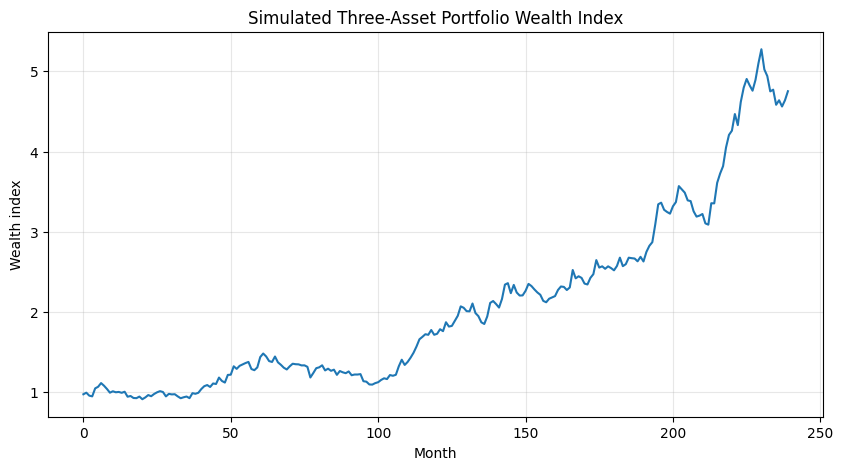

In [20]:
wealth_index = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(wealth_index)
plt.xlabel("Month")
plt.ylabel("Wealth index")
plt.title("Simulated Three-Asset Portfolio Wealth Index")
plt.grid(True, alpha=0.3)
plt.show()

# 16. Capital Allocation with a Risk-Free Asset

Now introduce a risk-free asset with return \( R_f \).

Suppose an investor combines:

- a risk-free asset with return \( R_f \),
- a risky portfolio \( P \) with expected return \( \mathbb{E}[R_P] \) and standard deviation \( \sigma_P \).

Let \( y \) be the weight in the risky portfolio.

Then the weight in the risk-free asset is \( 1-y \).

The complete portfolio return is:

$$
R_C = (1-y)R_f + yR_P
$$

Expected return is:

$$
\mathbb{E}[R_C]
=
R_f + y(\mathbb{E}[R_P]-R_f)
$$

Standard deviation is:

$$
\sigma_C = |y|\sigma_P
$$

because the risk-free asset has zero variance and zero covariance with the risky asset.

If \( 0<y<1 \), the investor holds both the risk-free asset and the risky portfolio.

If \( y=1 \), all wealth is invested in the risky portfolio.

If \( y>1 \), the investor borrows at the risk-free rate and invests more than 100% of wealth in the risky portfolio.

If \( y<0 \), the investor shorts the risky portfolio and holds more than 100% in the risk-free asset.

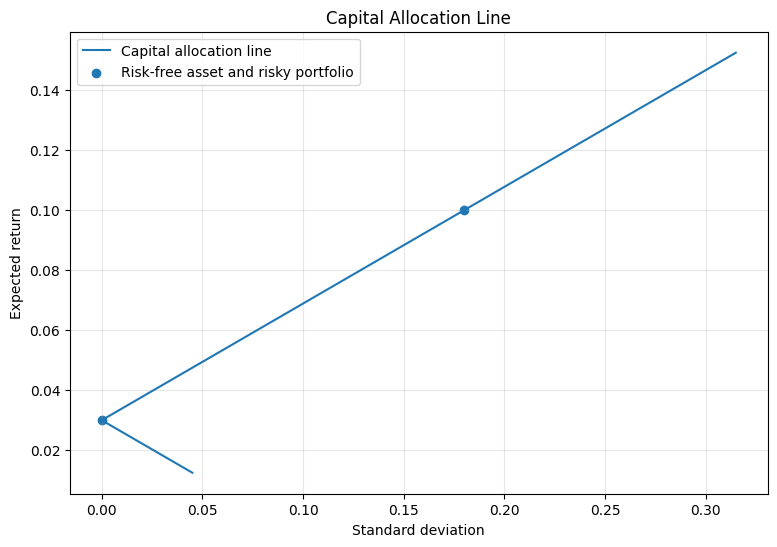

In [21]:
rf = 0.03
mu_P = 0.10
sigma_P = 0.18

y_values = np.linspace(-0.25, 1.75, 201)
mu_C = rf + y_values * (mu_P - rf)
sigma_C = np.abs(y_values) * sigma_P

plt.figure(figsize=(9, 6))
plt.plot(sigma_C, mu_C, label="Capital allocation line")
plt.scatter([0, sigma_P], [rf, mu_P], marker="o", label="Risk-free asset and risky portfolio")
plt.xlabel("Standard deviation")
plt.ylabel("Expected return")
plt.title("Capital Allocation Line")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The slope of the capital allocation line is the Sharpe ratio of the risky portfolio:

$$
S_P
=
\frac{\mathbb{E}[R_P]-R_f}{\sigma_P}
$$

The Sharpe ratio measures reward per unit of total volatility.

In [22]:
sharpe_P = (mu_P - rf) / sigma_P
print(f"Sharpe ratio of risky portfolio P: {sharpe_P:.4f}")

Sharpe ratio of risky portfolio P: 0.3889


# 17. The Tangency Portfolio

With many risky assets, every risky portfolio can be combined with the risk-free asset.

The best risky portfolio is the one that produces the steepest capital allocation line.

That portfolio maximizes the Sharpe ratio:

$$
\max_{\mathbf{w}}
\frac{\mathbf{w}'\boldsymbol{\mu}-R_f}
{\sqrt{\mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}}}
$$

subject to:

$$
\mathbf{1}'\mathbf{w}=1
$$

This Sharpe-maximizing risky portfolio is the **tangency portfolio**.

It is called the tangency portfolio because the capital allocation line through the risk-free asset is tangent to the efficient frontier of risky assets.

When short selling is allowed and the covariance matrix is invertible, the tangency portfolio has the closed-form solution:

$$
\mathbf{w}_T
=
\frac{\boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu}-R_f\mathbf{1})}
{\mathbf{1}'\boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu}-R_f\mathbf{1})}
$$

This formula says that optimal risky weights depend on:

1. expected excess returns,
2. variances,
3. covariances.

In [23]:
ones = np.ones(len(mu3))
excess_mu = mu3 - rf * ones
inv_Sigma3 = np.linalg.inv(Sigma3)

w_tangency = inv_Sigma3 @ excess_mu
w_tangency = w_tangency / (ones @ inv_Sigma3 @ excess_mu)

mu_tangency = w_tangency @ mu3
sigma_tangency = np.sqrt(w_tangency @ Sigma3 @ w_tangency)
sharpe_tangency = (mu_tangency - rf) / sigma_tangency

pd.DataFrame({
    "Asset": ["Asset 1", "Asset 2", "Asset 3"],
    "Tangency Weight": w_tangency
})

,Asset,Tangency Weight
0,Asset 1,0.5066
1,Asset 2,0.2599
2,Asset 3,0.2335


In [24]:
print(f"Tangency portfolio expected return: {mu_tangency:.2%}")
print(f"Tangency portfolio standard deviation: {sigma_tangency:.2%}")
print(f"Tangency portfolio Sharpe ratio: {sharpe_tangency:.4f}")
print(f"Sum of weights: {w_tangency.sum():.4f}")

Tangency portfolio expected return: 8.91%
Tangency portfolio standard deviation: 12.20%
Tangency portfolio Sharpe ratio: 0.4842
Sum of weights: 1.0000


Some tangency weights may be negative or greater than one when short selling is allowed.

That is not a mathematical error. It means the unconstrained Sharpe-maximizing portfolio uses short positions or leverage among the risky assets.

In practice, many investors face short-selling constraints, leverage limits, mandate restrictions, transaction costs, taxes, or liquidity limits. Those constraints change the optimization problem.

# 18. Tracing the Minimum-Variance Frontier with Many Risky Assets

The Markowitz problem can be stated in several equivalent ways.

One common version minimizes variance for a target expected return:

$$
\min_{\mathbf{w}} \quad \mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
$$

subject to:

$$
\mathbf{w}'\boldsymbol{\mu}=\mu_p
$$

and:

$$
\mathbf{1}'\mathbf{w}=1
$$

By solving this problem for many values of \( \mu_p \), we trace the minimum-variance frontier.

The upper branch of that frontier is the efficient frontier.

The global minimum-variance portfolio solves:

$$
\min_{\mathbf{w}} \quad \mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
$$

subject to:

$$
\mathbf{1}'\mathbf{w}=1
$$

With short selling allowed, the closed-form solution is:

$$
\mathbf{w}_{GMV}
=
\frac{\boldsymbol{\Sigma}^{-1}\mathbf{1}}
{\mathbf{1}'\boldsymbol{\Sigma}^{-1}\mathbf{1}}
$$

In [25]:
w_gmv = inv_Sigma3 @ ones
w_gmv = w_gmv / (ones @ inv_Sigma3 @ ones)

mu_gmv = w_gmv @ mu3
sigma_gmv = np.sqrt(w_gmv @ Sigma3 @ w_gmv)

pd.DataFrame({
    "Asset": ["Asset 1", "Asset 2", "Asset 3"],
    "GMV Weight": w_gmv
})

,Asset,GMV Weight
0,Asset 1,0.8689
1,Asset 2,0.0820
2,Asset 3,0.0492


In [26]:
print(f"Global minimum-variance expected return: {mu_gmv:.2%}")
print(f"Global minimum-variance standard deviation: {sigma_gmv:.2%}")
print(f"Sum of weights: {w_gmv.sum():.4f}")

Global minimum-variance expected return: 6.72%
Global minimum-variance standard deviation: 9.68%
Sum of weights: 1.0000


For target-return frontier portfolios, we can use the standard closed-form solution.

Define:

$$
A = \mathbf{1}'\boldsymbol{\Sigma}^{-1}\mathbf{1}
$$

$$
B = \mathbf{1}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}
$$

$$
C = \boldsymbol{\mu}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}
$$

$$
D = AC-B^2
$$

For a target return \( \mu_p \), the minimum-variance portfolio is:

$$
\mathbf{w}(\mu_p)
=
\boldsymbol{\Sigma}^{-1}
\left[
\frac{C-B\mu_p}{D}\mathbf{1}
+
\frac{A\mu_p-B}{D}\boldsymbol{\mu}
\right]
$$

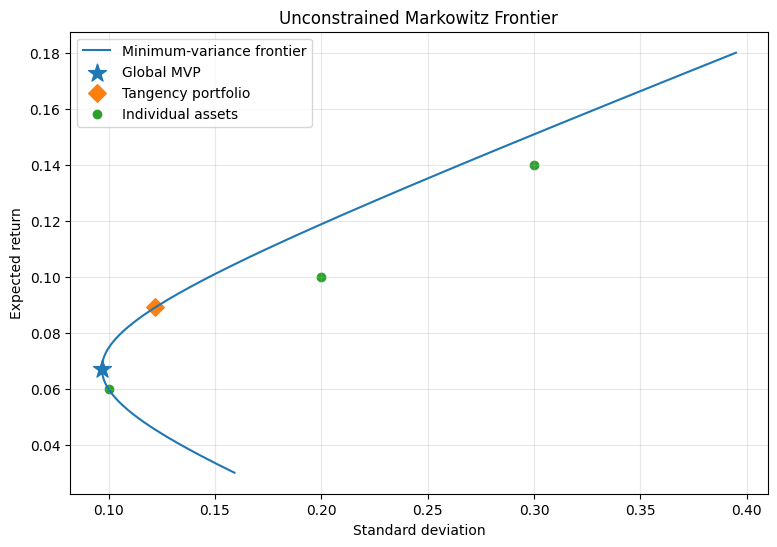

In [27]:
A = ones @ inv_Sigma3 @ ones
B = ones @ inv_Sigma3 @ mu3
C = mu3 @ inv_Sigma3 @ mu3
D = A*C - B**2

target_returns = np.linspace(0.03, 0.18, 200)
frontier_weights = []
frontier_sigmas = []

for target in target_returns:
    w_target = inv_Sigma3 @ (((C - B*target)/D) * ones + ((A*target - B)/D) * mu3)
    frontier_weights.append(w_target)
    frontier_sigmas.append(np.sqrt(w_target @ Sigma3 @ w_target))

frontier_weights = np.array(frontier_weights)
frontier_sigmas = np.array(frontier_sigmas)

plt.figure(figsize=(9, 6))
plt.plot(frontier_sigmas, target_returns, label="Minimum-variance frontier")
plt.scatter([sigma_gmv], [mu_gmv], marker="*", s=180, label="Global MVP")
plt.scatter([sigma_tangency], [mu_tangency], marker="D", s=80, label="Tangency portfolio")
plt.scatter(np.sqrt(np.diag(Sigma3)), mu3, marker="o", label="Individual assets")
plt.xlabel("Standard deviation")
plt.ylabel("Expected return")
plt.title("Unconstrained Markowitz Frontier")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The lower branch of the minimum-variance frontier is inefficient.

For the same level of risk, an investor can move to the upper branch and receive a higher expected return.

The upper branch beginning at the global minimum-variance portfolio is the efficient frontier.

# 19. The Capital Market Line

Once the risk-free asset is introduced, the best opportunity set is the line from the risk-free asset through the tangency portfolio.

This line is the **capital market line**, or CML.

Its equation is:

$$
\mathbb{E}[R_C]
=
R_f
+
\frac{\mathbb{E}[R_T]-R_f}{\sigma_T}\sigma_C
$$

where \( T \) is the tangency portfolio.

The slope of the CML is the Sharpe ratio of the tangency portfolio.

All investors who agree on expected returns, variances, covariances, and the risk-free rate choose the same tangency portfolio of risky assets. They differ only in how much they allocate to it.

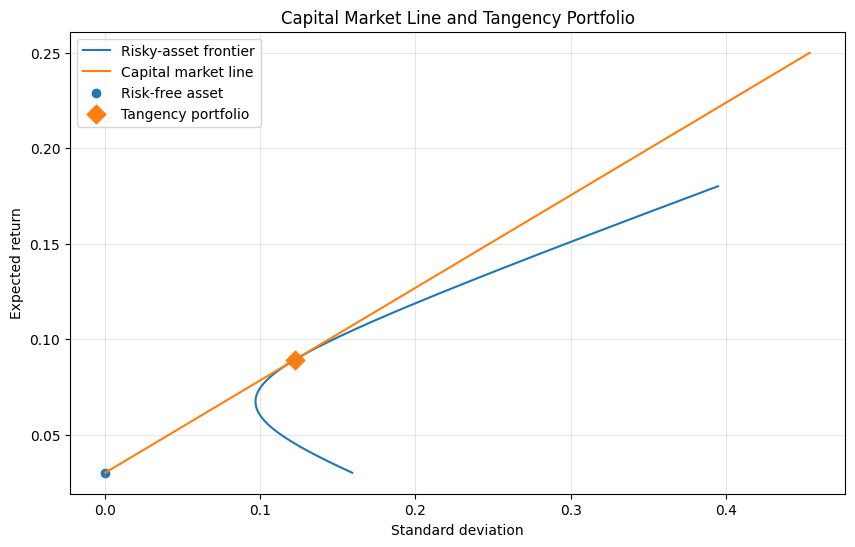

In [28]:
sigma_cml = np.linspace(0, max(frontier_sigmas)*1.15, 200)
mu_cml = rf + sharpe_tangency * sigma_cml

plt.figure(figsize=(10, 6))
plt.plot(frontier_sigmas, target_returns, label="Risky-asset frontier")
plt.plot(sigma_cml, mu_cml, label="Capital market line")
plt.scatter([0], [rf], marker="o", label="Risk-free asset")
plt.scatter([sigma_tangency], [mu_tangency], marker="D", s=90, label="Tangency portfolio")
plt.xlabel("Standard deviation")
plt.ylabel("Expected return")
plt.title("Capital Market Line and Tangency Portfolio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The CML dominates all inefficient risky portfolios.

A rational mean-variance investor will not combine the risk-free asset with an arbitrary risky portfolio if a higher-Sharpe tangency portfolio is available.

# 20. The Optimal Complete Portfolio

The tangency portfolio gives the best risky fund.

The investor's risk aversion determines how much of total wealth is allocated to that risky fund.

Using mean-variance utility:

$$
U = \mathbb{E}[R_C] - \frac{A}{2}\sigma_C^2
$$

where \( A \) is the investor's coefficient of risk aversion.

If the investor allocates fraction \( y \) to the tangency portfolio, then:

$$
\mathbb{E}[R_C]
=
R_f + y(\mathbb{E}[R_T]-R_f)
$$

and:

$$
\sigma_C = y\sigma_T
$$

Substitute into utility:

$$
U(y)
=
R_f + y(\mathbb{E}[R_T]-R_f)
-
\frac{A}{2}y^2\sigma_T^2
$$

The first-order condition gives:

$$
y^*
=
\frac{\mathbb{E}[R_T]-R_f}{A\sigma_T^2}
$$

More risk-averse investors choose smaller \( y^* \).

Less risk-averse investors choose larger \( y^* \), possibly greater than one.

In [29]:
risk_aversion_values = np.array([1, 2, 3, 5, 8, 12])

y_star = (mu_tangency - rf) / (risk_aversion_values * sigma_tangency**2)
complete_mu = rf + y_star * (mu_tangency - rf)
complete_sigma = y_star * sigma_tangency

pd.DataFrame({
    "Risk Aversion A": risk_aversion_values,
    "Weight in Tangency Portfolio y*": y_star,
    "Weight in Risk-Free Asset 1-y*": 1 - y_star,
    "Expected Return": complete_mu,
    "Standard Deviation": complete_sigma
})

,Risk Aversion A,Weight in Tangency Portfolio y*,Weight in Risk-Free Asset 1-y*,Expected Return,Standard Deviation
0,1,3.9685,-2.9685,0.2644,0.4842
1,2,1.9843,-0.9843,0.1472,0.2421
2,3,1.3228,-0.3228,0.1081,0.1614
3,5,0.7937,0.2063,0.0769,0.0968
4,8,0.4961,0.5039,0.0593,0.0605
5,12,0.3307,0.6693,0.0495,0.0403


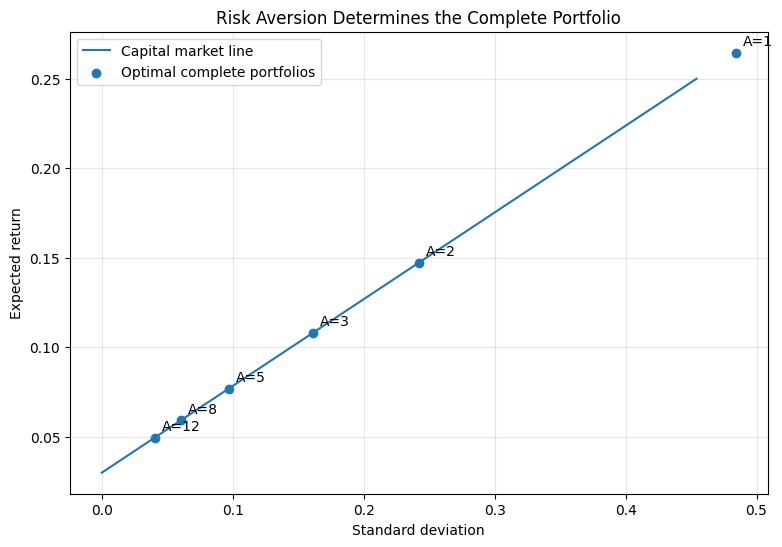

In [30]:
plt.figure(figsize=(9, 6))
plt.plot(sigma_cml, mu_cml, label="Capital market line")
plt.scatter(complete_sigma, complete_mu, marker="o", label="Optimal complete portfolios")
for A_val, x, y in zip(risk_aversion_values, complete_sigma, complete_mu):
    plt.annotate(f"A={A_val}", (x, y), textcoords="offset points", xytext=(5,5))

plt.xlabel("Standard deviation")
plt.ylabel("Expected return")
plt.title("Risk Aversion Determines the Complete Portfolio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Investors with different risk aversion coefficients can hold the same risky portfolio but in different proportions.

This is the core intuition behind the separation property.

# 21. The Separation Property

The **separation property** says that the portfolio choice problem can be separated into two decisions:

1. Choose the optimal risky portfolio.
2. Choose how much to allocate to that risky portfolio versus the risk-free asset.

The first decision depends on capital market opportunities:

- expected returns,
- variances,
- covariances,
- the risk-free rate.

The second decision depends on investor preferences:

- risk aversion,
- horizon,
- income risk,
- constraints,
- taxes,
- liquidity needs.

Under the strong assumptions of classical mean-variance theory, all investors hold the same tangency portfolio of risky assets and differ only in the risk-free/risky allocation.

This is also the intuition behind diversified passive investing.

If investors agree on the inputs and markets are in equilibrium, the market portfolio is the natural risky portfolio.

# 22. The Market Portfolio and the Diversified Passive Strategy

The **market portfolio** is the value-weighted portfolio of all risky assets in the market.

A value-weighted equity index approximates the equity-market component of the market portfolio.

The logic of a diversified passive strategy is:

1. Most firm-specific risk can be diversified away.
2. Bearing diversifiable risk should not command a risk premium in equilibrium.
3. Investors are compensated mainly for systematic risk.
4. A broad market portfolio provides exposure to systematic risk at low cost.
5. Investors can adjust risk by changing the allocation between the market portfolio and safe assets.

This is the conceptual basis for index funds and diversified passive investing.

The argument does not imply that all active management is impossible. Rather, it says that undiversified idiosyncratic risk is usually not a reliable source of compensation.

# 23. Short-Selling Constraints

The unconstrained Markowitz solution may prescribe negative weights.

Many investors cannot or do not want to short assets.

A long-only constraint requires:

$$
w_i \ge 0
$$

for all assets.

The optimization problem becomes:

$$
\min_{\mathbf{w}} \quad \mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
$$

subject to:

$$
\mathbf{w}'\boldsymbol{\mu} = \mu_p
$$

$$
\mathbf{1}'\mathbf{w}=1
$$

$$
w_i \ge 0
$$

Short-selling constraints typically make the frontier worse: for a given expected return, the investor may have to accept more risk.

But constraints may also make the portfolio more realistic.

In [31]:
num_portfolios = 50_000
raw_weights = np.random.dirichlet(np.ones(3), size=num_portfolios)

portfolio_returns_random = raw_weights @ mu3
portfolio_vars_random = np.einsum("ij,jk,ik->i", raw_weights, Sigma3, raw_weights)
portfolio_stds_random = np.sqrt(portfolio_vars_random)
portfolio_sharpes_random = (portfolio_returns_random - rf) / portfolio_stds_random

best_idx = np.argmax(portfolio_sharpes_random)
w_longonly_tangency_approx = raw_weights[best_idx]
mu_longonly_tangency = portfolio_returns_random[best_idx]
sigma_longonly_tangency = portfolio_stds_random[best_idx]
sharpe_longonly_tangency = portfolio_sharpes_random[best_idx]

pd.DataFrame({
    "Asset": ["Asset 1", "Asset 2", "Asset 3"],
    "Approx Long-Only Tangency Weight": w_longonly_tangency_approx
})

,Asset,Approx Long-Only Tangency Weight
0,Asset 1,0.5089
1,Asset 2,0.2580
2,Asset 3,0.2331


Approx long-only tangency expected return: 8.90%
Approx long-only tangency standard deviation: 12.18%
Approx long-only tangency Sharpe ratio: 0.4842


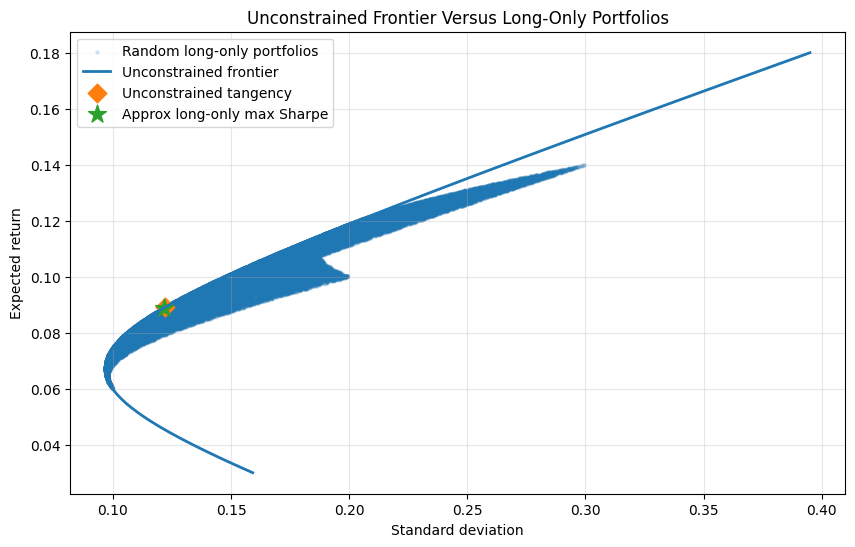

In [32]:
print(f"Approx long-only tangency expected return: {mu_longonly_tangency:.2%}")
print(f"Approx long-only tangency standard deviation: {sigma_longonly_tangency:.2%}")
print(f"Approx long-only tangency Sharpe ratio: {sharpe_longonly_tangency:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(portfolio_stds_random, portfolio_returns_random, s=5, alpha=0.15, label="Random long-only portfolios")
plt.plot(frontier_sigmas, target_returns, linewidth=2, label="Unconstrained frontier")
plt.scatter([sigma_tangency], [mu_tangency], marker="D", s=90, label="Unconstrained tangency")
plt.scatter([sigma_longonly_tangency], [mu_longonly_tangency], marker="*", s=180, label="Approx long-only max Sharpe")
plt.xlabel("Standard deviation")
plt.ylabel("Expected return")
plt.title("Unconstrained Frontier Versus Long-Only Portfolios")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The random long-only cloud lies inside the unconstrained opportunity set.

The long-only Sharpe-maximizing portfolio may differ from the unconstrained tangency portfolio.

This is one reason real-world portfolio optimization depends heavily on constraints.

# 24. Worked Example 3: Building a Complete Portfolio

Suppose an investor has risk aversion \( A=4 \).

Using the tangency portfolio calculated above:

$$
y^*
=
\frac{\mathbb{E}[R_T]-R_f}{A\sigma_T^2}
$$

The investor allocates \( y^* \) of wealth to the tangency portfolio and \( 1-y^* \) to the risk-free asset.

If \( y^*>1 \), the investor borrows and leverages the tangency portfolio.

If \( y^*<1 \), the investor holds some risk-free asset.

In [33]:
A_investor = 4

y_opt = (mu_tangency - rf) / (A_investor * sigma_tangency**2)
rf_weight = 1 - y_opt
complete_asset_weights = y_opt * w_tangency

complete_portfolio_summary = pd.DataFrame({
    "Component": ["Risk-free asset", "Asset 1", "Asset 2", "Asset 3"],
    "Weight in Complete Portfolio": np.r_[rf_weight, complete_asset_weights]
})

mu_complete = rf + y_opt*(mu_tangency-rf)
sigma_complete = y_opt*sigma_tangency

display(complete_portfolio_summary)

print(f"Investor risk aversion A: {A_investor}")
print(f"Weight in tangency portfolio: {y_opt:.4f}")
print(f"Weight in risk-free asset: {rf_weight:.4f}")
print(f"Complete portfolio expected return: {mu_complete:.2%}")
print(f"Complete portfolio standard deviation: {sigma_complete:.2%}")

,Component,Weight in Complete Portfolio
0,Risk-free asset,0.0079
1,Asset 1,0.5026
2,Asset 2,0.2579
3,Asset 3,0.2316


Investor risk aversion A: 4
Weight in tangency portfolio: 0.9921
Weight in risk-free asset: 0.0079
Complete portfolio expected return: 8.86%
Complete portfolio standard deviation: 12.10%


The complete portfolio weights show the final economic exposure.

The investor does not merely hold the risky tangency portfolio. The investor holds a complete portfolio that combines the tangency portfolio with borrowing or lending.

# 25. Worked Example 4: Recovering the Implied Risk Aversion Parameter

If we observe an investor's allocation to the tangency portfolio, we can infer the mean-variance risk aversion parameter that rationalizes that allocation.

From:

$$
y^*
=
\frac{\mathbb{E}[R_T]-R_f}{A\sigma_T^2}
$$

solve for \( A \):

$$
A
=
\frac{\mathbb{E}[R_T]-R_f}{y^*\sigma_T^2}
$$

This is the same idea introduced in Lecture 2: if investors allocate according to risk aversion, we can infer the risk aversion parameter from their portfolio choice.

In [34]:
observed_y_values = np.array([0.40, 0.60, 1.00, 1.50])
implied_A = (mu_tangency - rf) / (observed_y_values * sigma_tangency**2)

pd.DataFrame({
    "Observed Weight in Tangency Portfolio": observed_y_values,
    "Implied Risk Aversion A": implied_A
})

,Observed Weight in Tangency Portfolio,Implied Risk Aversion A
0,0.4000,9.9213
1,0.6000,6.6142
2,1.0000,3.9685
3,1.5000,2.6457


Higher observed risky allocations imply lower risk aversion.

Lower observed risky allocations imply higher risk aversion.

This inference depends on the assumed expected return, risk-free rate, and volatility of the tangency portfolio.

# 26. Estimation Risk and Practical Caution

Markowitz optimization is powerful, but it is sensitive to inputs.

Small changes in expected returns, variances, and covariances can produce large changes in optimal weights.

Expected returns are especially difficult to estimate.

Covariances are often more stable than expected returns, but they also vary through time.

Practical portfolio construction often uses:

- constraints,
- shrinkage estimators,
- robust optimization,
- factor models,
- Bayesian or Black-Litterman methods,
- risk budgeting,
- maximum diversification methods,
- equal-weighted or value-weighted benchmarks.

The core lesson remains:

> Portfolio risk depends on covariances, not merely on individual asset volatilities.

# 27. Summary of Key Formulas

## Portfolio expected return

$$
\mathbb{E}[R_p] = \mathbf{w}'\boldsymbol{\mu}
$$

## Portfolio variance

$$
\sigma_p^2 = \mathbf{w}'\boldsymbol{\Sigma}\mathbf{w}
$$

## Two-asset portfolio variance

$$
\sigma_p^2
=
w_A^2\sigma_A^2
+
w_B^2\sigma_B^2
+
2w_Aw_B\rho_{AB}\sigma_A\sigma_B
$$

## Variance as covariance with itself

$$
\operatorname{Var}(R_i)=\operatorname{Cov}(R_i,R_i)
$$

## Minimum-variance weight with two risky assets

$$
w_A^{MVP}
=
\frac{\sigma_B^2-\sigma_{AB}}
{\sigma_A^2+\sigma_B^2-2\sigma_{AB}}
$$

## Risky/risk-free complete portfolio expected return

$$
\mathbb{E}[R_C]
=
R_f+y(\mathbb{E}[R_P]-R_f)
$$

## Risky/risk-free complete portfolio standard deviation

$$
\sigma_C = |y|\sigma_P
$$

## Sharpe ratio

$$
S_P = \frac{\mathbb{E}[R_P]-R_f}{\sigma_P}
$$

## Tangency portfolio

$$
\mathbf{w}_T
=
\frac{\boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu}-R_f\mathbf{1})}
{\mathbf{1}'\boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu}-R_f\mathbf{1})}
$$

## Global minimum-variance portfolio

$$
\mathbf{w}_{GMV}
=
\frac{\boldsymbol{\Sigma}^{-1}\mathbf{1}}
{\mathbf{1}'\boldsymbol{\Sigma}^{-1}\mathbf{1}}
$$

## Optimal allocation to tangency portfolio

$$
y^*
=
\frac{\mathbb{E}[R_T]-R_f}{A\sigma_T^2}
$$

## Implied risk aversion

$$
A
=
\frac{\mathbb{E}[R_T]-R_f}{y^*\sigma_T^2}
$$

# 28. Conceptual Takeaways

1. Diversification works because imperfectly correlated risks offset each other.

2. Independent firm-specific risk can be diversified away.

3. Systematic risk remains because many assets are exposed to common economic shocks.

4. Portfolio expected return is a weighted average of asset expected returns.

5. Portfolio variance depends on variances and covariances.

6. The variance of an asset's returns is its covariance with itself.

7. Negative correlation creates especially powerful diversification benefits.

8. Hedge assets can be valuable even when their expected returns are low.

9. Portfolio weights below 0 imply short positions. Portfolio weights above 1 imply leverage.

10. The minimum-variance portfolio minimizes risk among risky-asset combinations.

11. The efficient frontier contains portfolios with the highest expected return for each level of risk.

12. The tangency portfolio maximizes the Sharpe ratio.

13. With a risk-free asset, the capital market line dominates inefficient risky portfolios.

14. The optimal complete portfolio combines the risk-free asset and the tangency portfolio.

15. More risk-averse investors hold less of the risky tangency portfolio.

16. The separation property divides the investment problem into portfolio selection and risk allocation.

17. Constraints such as no short selling change the feasible opportunity set.

18. Markowitz optimization is conceptually elegant but practically sensitive to estimation error.